In [30]:
# Import necessary libraries
import pandas as pd
import numpy as np
import torch
from importlib import reload
import itertools
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import re
from scipy.stats import qmc
import random


In [31]:
# Bounds for the entire space including N1 to N12 ? (or maybe N10)
# PbI2:BAAc:MAI = 1 : (2/n) : [(n+1)/n]
# PbI2:BAAc:MAI = 1 : (2/n) : [(n+1)/n]
theoretical_N1 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 2.00,  
                  'R MAI': 2.00,
                  'R PbI2': 1,
                  }
theoretical_N2 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 1.00,  
                  'R MAI': 1.50,
                  'R PbI2': 1,
                  }
theoretical_N3 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 0.667,  # aprox to 0.675
                  'R MAI': 1.333, # aprox to 1.325
                  'R PbI2': 1,
                  }
theoretical_N4 = {'Anneal Time': 10, # min
                  'Temperature': 95, # C
                  'R BAAc': 0.5,  
                  'R MAI': 1.25,
                  'R PbI2': 1,
                  }
theoretical_N10 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 0.20,  
                  'R MAI': 1.10,
                  'R PbI2': 1,
                  }
# PbI2:BAAc:MAI = 1 : (2/n) : [(n+1)/n]
theoretical_N12 = {'Anneal Time': 10, # min
                  'Temperature': 150, # C
                  'R BAAc': 0.17,  
                  'R MAI': 1.08,
                  'R PbI2': 1,
                  }
bounds = {
    'PbI2': 1, 
    'BAAc': (0.0, 2.5 +0.1), # or (0.2, 2.00)
    'MAI': (0.8, 2.5+0.1), # or (0.58, 2.00) 
    'Anneal Time': (5 - 5, 60 + 5 ),
    'Anneal Temp': (60 - 10, 150 + 10)
}


def BAAc_theoretical(n):
    return 2/n
def MAI_theoretical(n):
    return (n+1)/n


In [32]:
BAAc_theoretical_list = [BAAc_theoretical(n) for n in range(1,13)]
MAI_theoretical_list = [MAI_theoretical(n) for n in range(1,13)]
theo_df = pd.DataFrame()
theo_df['R BAAc'] = BAAc_theoretical_list
theo_df['R MAI'] = MAI_theoretical_list
theo_df['R PbI2'] = 1.0 
theo_df['Nn'] = [f'N{n}' for n in range(1,13)]
theo_df

,R BAAc,R MAI,R PbI2,Nn
0,2.000000,2.000000,1.0,N1
1,1.000000,1.500000,1.0,N2
2,0.666667,1.333333,1.0,N3
3,0.500000,1.250000,1.0,N4
4,0.400000,1.200000,1.0,N5
5,0.333333,1.166667,1.0,N6
6,0.285714,1.142857,1.0,N7
7,0.250000,1.125000,1.0,N8
8,0.222222,1.111111,1.0,N9
9,0.200000,1.100000,1.0,N10


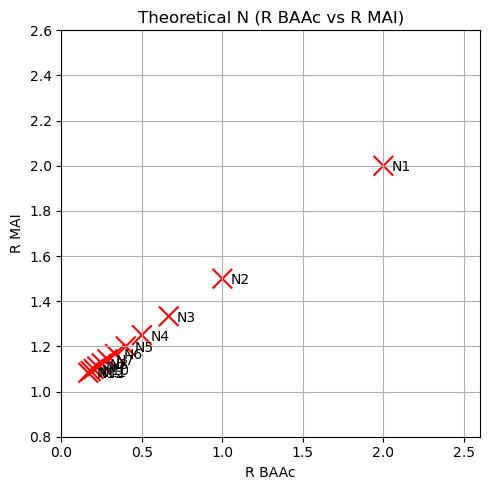

In [33]:

# 2D scatter: R BAAc vs R MAI, color by Temperature, size by R PbI2
plt.figure(figsize=(5,5))
sc = plt.scatter(theo_df['R BAAc'], theo_df['R MAI'],
                s=200*theo_df['R PbI2'], color ='r' , marker='x')
for i, lab in enumerate(theo_df['Nn']):
    plt.annotate(lab, (theo_df['R BAAc'].iloc[i], theo_df['R MAI'].iloc[i]),
                 textcoords="offset points", xytext=(6,-4))
plt.xlabel('R BAAc')
plt.ylabel('R MAI')
plt.xlim(bounds['BAAc'])
plt.ylim(bounds['MAI'])
# cbar = plt.colorbar(sc)
# cbar.set_label('Temperature (°C)')
plt.title('Theoretical N (R BAAc vs R MAI)')
plt.grid(True)
plt.tight_layout()
plt.show()

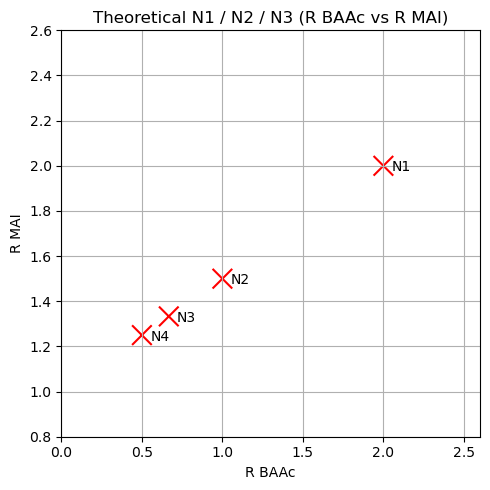

In [34]:
# N1 Initial
# Containts N1, N2, and N3 theoretical

# create a small dataframe with the theoretical points and plot them (2D + 3D)
# theo_df = pd.DataFrame([theoretical_N1, theoretical_N2, theoretical_N3, theoretical_N10], index=['N1', 'N2', 'N3', 'N10'])
theo_df = pd.DataFrame([theoretical_N1, theoretical_N2, theoretical_N3, theoretical_N4], index=['N1', 'N2', 'N3','N4'])
# 2D scatter: R BAAc vs R MAI, color by Temperature, size by R PbI2
plt.figure(figsize=(5,5))
sc = plt.scatter(theo_df['R BAAc'], theo_df['R MAI'],
                s=200*theo_df['R PbI2'], color ='r' , marker='x')
for i, lab in enumerate(theo_df.index):
    plt.annotate(lab, (theo_df['R BAAc'].iloc[i], theo_df['R MAI'].iloc[i]),
                 textcoords="offset points", xytext=(6,-4))
plt.xlabel('R BAAc')
plt.ylabel('R MAI')
plt.xlim(bounds['BAAc'])
plt.ylim(bounds['MAI'])
# cbar = plt.colorbar(sc)
# cbar.set_label('Temperature (°C)')
plt.title('Theoretical N1 / N2 / N3 (R BAAc vs R MAI)')
plt.grid(True)
plt.tight_layout()
plt.show()

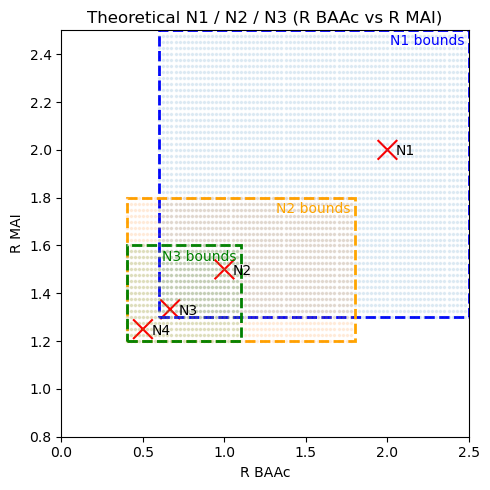

In [43]:
from matplotlib.patches import Rectangle

N1_bounds = [[5, 60], [60, 150], [0.6, 2.5],[1.3, 2.5]] #  Time, Temp, BAAc, MAI,
N2_bounds_01 = [[5, 60],[60, 150] ,[0.40, 1.1],[1.2, 1.6]] 
N2_bounds_02 = [[5, 60],[60, 150] ,[0.40, 1.8],[1.2, 1.8]]
N3_bounds = [[5, 60], [60, 150], [0.40, 1.1],[1.2, 1.6]] 

MAI_bounds = [N1_bounds[3], N2_bounds_02[3], N3_bounds[3]]
BAAc_bounds = [N1_bounds[2], N2_bounds_02[2], N3_bounds[2]]
color = ['blue', 'orange', 'green']
minor_colors = ['tab:blue', 'tab:orange', 'tab:green']
bound_labels = ['N1 bounds', 'N2 bounds', 'N3 bounds']

# meshgrid of N1, N2, N3:  MAI vs BAAc
N1_baac_range = np.arange(N1_bounds[2][0], N1_bounds[2][1], 0.025)
N1_mai_range = np.arange(N1_bounds[3][0], N1_bounds[3][1], 0.025)
N1_baac_grid, N1_mai_grid = np.meshgrid(N1_baac_range, N1_mai_range)

N2_baac_range = np.arange(N2_bounds_02[2][0], N2_bounds_02[2][1], 0.025)
N2_mai_range = np.arange(N2_bounds_02[3][0], N2_bounds_02[3][1], 0.025)
N2_baac_grid, N2_mai_grid = np.meshgrid(N2_baac_range, N2_mai_range)

N3_baac_range = np.arange(N3_bounds[2][0], N3_bounds[2][1], 0.025)
N3_mai_range = np.arange(N3_bounds[3][0], N3_bounds[3][1], 0.025)
N3_baac_grid, N3_mai_grid = np.meshgrid(N3_baac_range, N3_mai_range)

baac_list =[N1_baac_grid, N2_baac_grid, N3_baac_grid]
mai_list = [N1_mai_grid, N2_mai_grid, N3_mai_grid]



plt.figure(figsize=(5,5))
sc = plt.scatter(theo_df['R BAAc'], theo_df['R MAI'],
                s=200*theo_df['R PbI2'], color ='r' , marker='x')
for i, lab in enumerate(theo_df.index):
    plt.annotate(lab, (theo_df['R BAAc'].iloc[i], theo_df['R MAI'].iloc[i]),
                 textcoords="offset points", xytext=(6,-4))
    
    if i >= 3:
        continue  # Only draw bounds for N1, N2, N3
    ax = plt.gca()
    x0, x1 = BAAc_bounds[i]  # BAAc bounds
    y0, y1 = MAI_bounds[i]  # MAI bounds
    rect = Rectangle((x0, y0), x1 - x0, y1 - y0,
                     linewidth=2, edgecolor=color[i], facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.annotate(bound_labels[i],
                xy=(x1, y1),
                xytext=(-57, -13),
                textcoords='offset points',
                color=color[i],
                ha='left',
                va='bottom',
                fontsize=10)
    plt.scatter(baac_list[i].ravel(), mai_list[i].ravel(), s=10, c=minor_colors[i], alpha=0.1, marker='.')

plt.xlabel('R BAAc')
plt.ylabel('R MAI')
plt.xlim(bounds['BAAc'])
plt.ylim(bounds['MAI'])
# cbar = plt.colorbar(sc)
# cbar.set_label('Temperature (°C)')
plt.title('Theoretical N1 / N2 / N3 (R BAAc vs R MAI)')
# plt.grid(True)
plt.tight_layout()
plt.show()



(0.8, 2.5)

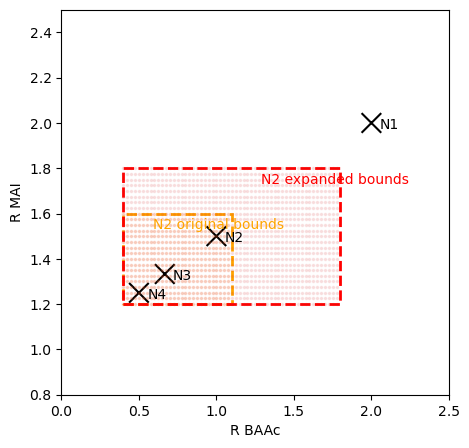

In [58]:
N2_bounds_01 = [[5, 60],[60, 150] ,[0.40, 1.1],[1.2, 1.6]] 
N2_bounds_02 = [[5, 60],[60, 150] ,[0.40, 1.8],[1.2, 1.8]]

baac_list =[ N3_baac_grid, N2_baac_grid,]
mai_list = [ N3_mai_grid, N2_mai_grid,]

MAI_bounds = [ N2_bounds_01[3], N2_bounds_02[3]]
BAAc_bounds = [ N2_bounds_01[2], N2_bounds_02[2]]
color = ['orange', 'red']
minor_colors = ['tab:orange', 'tab:red']
bound_labels = [ 'N2 original bounds', 'N2 expanded bounds']

plt.figure(figsize=(5,5))
sc = plt.scatter(theo_df['R BAAc'], theo_df['R MAI'],
                s=200*theo_df['R PbI2'], color ='k' , marker='x')
for i, lab in enumerate(theo_df.index):
    plt.annotate(lab, (theo_df['R BAAc'].iloc[i], theo_df['R MAI'].iloc[i]),
                 textcoords="offset points", xytext=(6,-4))
    
    if i >= 2:
        continue  # Only draw bounds for N1, N2, N3
    ax = plt.gca()
    x0, x1 = BAAc_bounds[i]  # BAAc bounds
    y0, y1 = MAI_bounds[i]  # MAI bounds
    rect = Rectangle((x0, y0), x1 - x0, y1 - y0,
                     linewidth=2, edgecolor=color[i], facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.annotate(bound_labels[i],
                xy=(x1, y1),
                xytext=(-57, -13),
                textcoords='offset points',
                color=color[i],
                ha='left',
                va='bottom',
                fontsize=10)
    plt.scatter(baac_list[i].ravel(), mai_list[i].ravel(), s=10, c=minor_colors[i], alpha=0.1, marker='.')

plt.xlabel('R BAAc')
plt.ylabel('R MAI')
plt.xlim(bounds['BAAc'])
plt.ylim(bounds['MAI'])

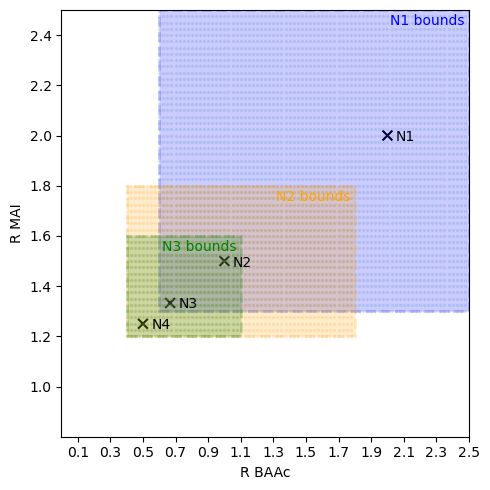

In [44]:
from matplotlib.patches import Rectangle

N1_bounds = [[5, 60], [60, 150], [0.6, 2.5],[1.3, 2.5]] #  Time, Temp, BAAc, MAI,
N2_bounds_01 = [[5, 60],[60, 150] ,[0.40, 1.1],[1.2, 1.6]] 
N2_bounds_02 = [[5, 60],[60, 150] ,[0.40, 1.8],[1.2, 1.8]]
N3_bounds = [[5, 60], [60, 150], [0.40, 1.1],[1.2, 1.6]] 

MAI_bounds = [N1_bounds[3], N2_bounds_02[3], N3_bounds[3]]
BAAc_bounds = [N1_bounds[2], N2_bounds_02[2], N3_bounds[2]]
color = ['blue', 'orange', 'green']

bound_labels = ['N1 bounds', 'N2 bounds', 'N3 bounds']

plt.figure(figsize=(5,5))
sc = plt.scatter(theo_df['R BAAc'], theo_df['R MAI'],
                s=50*theo_df['R PbI2'], color ='k' , marker='x')
for i, lab in enumerate(theo_df.index):
    plt.annotate(lab, (theo_df['R BAAc'].iloc[i], theo_df['R MAI'].iloc[i]),
                 textcoords="offset points", xytext=(6,-4))
    
    if i >= 3:
        continue  # Only draw bounds for N1, N2, N3
    
    ax = plt.gca()
    x0, x1 = BAAc_bounds[i]  # BAAc bounds
    y0, y1 = MAI_bounds[i]   # MAI bounds
    
    rect = Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        linewidth=2,
        edgecolor=color[i],
        facecolor=color[i],   # <-- shaded fill
        alpha=0.20,           # <-- transparency (0=transparent, 1=opaque)
        linestyle='--'
    )
    ax.add_patch(rect)

    ax.annotate(
        bound_labels[i],
        xy=(x1, y1),
        xytext=(-57, -13),
        textcoords='offset points',
        color=color[i],
        ha='left',
        va='bottom',
        fontsize=10
    )

    plt.scatter(baac_list[i].ravel(), mai_list[i].ravel(), s=10, c=minor_colors[i], alpha=0.1, marker='.')

plt.xlabel('R BAAc')
plt.ylabel('R MAI')
plt.xlim(bounds['BAAc'])
plt.ylim(bounds['MAI'])

# cbar = plt.colorbar(sc)
# cbar.set_label('Temperature (°C)')
# plt.title('Theoretical N1 / N2 / N3 (R BAAc vs R MAI)')
# plt.grid(True)
# plt.xticks(np.arange(0.1, 2.6, 0.05))
# plt.yticks(np.arange(1.0, 2.6, 0.05))
ax = plt.gca()
# major ticks every 0.2, minor ticks every 0.05
ax.set_xticks(np.arange(0.1, 2.6, 0.2))
ax.set_yticks(np.arange(1.0, 2.6, 0.2))
# ax.set_xticks(np.arange(0.1, 2.6, 0.05), minor=True)
# ax.set_yticks(np.arange(1.0, 2.6, 0.05), minor=True)

# # show grid for both major and minor ticks
# ax.grid(which='major', linestyle='--', linewidth=0.6, alpha=0.8)
# ax.grid(which='minor', linestyle='--', linewidth=0.6, alpha=0.8)

# plt.xticks(np.arange(0.1, 2.6, 0.2))
# plt.yticks(np.arange(1.0, 2.6, 0.2))

plt.tight_layout()
plt.show()




In [45]:
# meshgrid of time vs temp
time_range = np.arange(5, 61, 5)
temp_range = np.arange(60, 151, 5)
time_grid, temp_grid = np.meshgrid(time_range, temp_range)

# parameter design space
len(time_range) * len(temp_range)


228

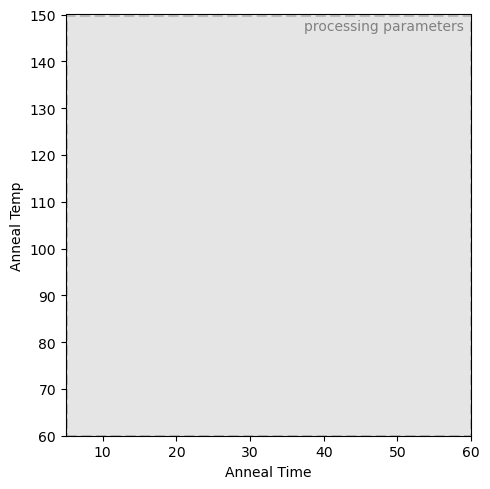

In [46]:
from matplotlib.patches import Rectangle

N1_bounds = [[5, 60], [60, 150], [0.6, 2.5],[1.3, 2.5]] #  Time, Temp, BAAc, MAI,
N2_bounds_01 = [[5, 60],[60, 150] ,[0.40, 1.1],[1.2, 1.6]] 
N2_bounds_02 = [[5, 60],[60, 150] ,[0.40, 1.8],[1.2, 1.8]]
N3_bounds = [[5, 60], [60, 150], [0.40, 1.1],[1.2, 1.6]] 



plt.figure(figsize=(5,5))
ax = plt.gca()
x0, x1 = N1_bounds[0]  # BAAc bounds
y0, y1 = N1_bounds[1]   # MAI bounds

rect = Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=2,
    edgecolor='k',
    facecolor='grey',   # <-- shaded fill
    alpha=0.20,           # <-- transparency (0=transparent, 1=opaque)
    linestyle='--'
)
ax.add_patch(rect)

ax.annotate(
    'processing parameters',
    xy=(x1, y1),
    xytext=(-120, -13),
    textcoords='offset points',
    color='grey',
    ha='left',
    va='bottom',
    fontsize=10
)
# plt.scatter(time_grid.ravel(), temp_grid.ravel(), s=10, c='k', alpha=0.1, marker='.')

plt.xlabel('Anneal Time')
plt.ylabel('Anneal Temp')
plt.xlim(bounds['Anneal Time'])
plt.ylim(bounds['Anneal Temp'])
# cbar = plt.colorbar(sc)
# cbar.set_label('Temperature (°C)')
# plt.title('Theoretical N1 / N2 / N3 (R BAAc vs R MAI)')
# plt.xticks(np.arange(5, 61, 5))
# plt.yticks(np.arange(60, 151, 5))
# plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.show()



# Benchmarking design space

In [47]:
# meshgrid of N1, N2, N3:  MAI vs BAAc
N1_baac_range = np.arange(N1_bounds[2][0], N1_bounds[2][1], 0.025)
N1_mai_range = np.arange(N1_bounds[3][0], N1_bounds[3][1], 0.025)
N1_baac_grid, N1_mai_grid = np.meshgrid(N1_baac_range, N1_mai_range)

N2_baac_range = np.arange(N2_bounds_02[2][0], N2_bounds_02[2][1], 0.025)
N2_mai_range = np.arange(N2_bounds_02[3][0], N2_bounds_02[3][1], 0.025)
N2_baac_grid, N2_mai_grid = np.meshgrid(N2_baac_range, N2_mai_range)

N3_baac_range = np.arange(N3_bounds[2][0], N3_bounds[2][1], 0.025)
N3_mai_range = np.arange(N3_bounds[3][0], N3_bounds[3][1], 0.025)
N3_baac_grid, N3_mai_grid = np.meshgrid(N3_baac_range, N3_mai_range)

# meshgrid of time vs temp
time_range = np.arange(5, 61, 5)
temp_range = np.arange(60, 151, 5)
time_grid, temp_grid = np.meshgrid(time_range, temp_range)

# parameter design space
param_space = len(time_range) * len(temp_range)
N1_space = len(N1_baac_range) * len(N1_mai_range)
N2_space = len(N2_baac_range) * len(N2_mai_range)
N3_space = len(N3_baac_range) * len(N3_mai_range)


total = param_space*N1_space + param_space*N2_space + param_space* N3_space
print('total design space that was explored: ', total)
print('parameter space: ', param_space)
print('N1 space: ', N1_space*param_space)
print('N2 space: ', N2_space*param_space)
print('N3 space: ', N3_space*param_space)  

total design space that was explored:  1259472
parameter space:  228
N1 space:  831744
N2 space:  319200
N3 space:  108528


In [48]:
# common grid over the full BAAc/MAI range
baac_min = min(N1_bounds[2][0], N2_bounds_02[2][0], N3_bounds[2][0])
baac_max = max(N1_bounds[2][1], N2_bounds_02[2][1], N3_bounds[2][1])
mai_min  = min(N1_bounds[3][0], N2_bounds_02[3][0], N3_bounds[3][0])
mai_max  = max(N1_bounds[3][1], N2_bounds_02[3][1], N3_bounds[3][1])

baac_range = np.arange(baac_min, baac_max, 0.05)
mai_range  = np.arange(mai_min,  mai_max,  0.05)
baac_grid, mai_grid = np.meshgrid(baac_range, mai_range)

# masks for each region
mask_N1 = (
    (baac_grid >= N1_bounds[2][0]) & (baac_grid <= N1_bounds[2][1]) &
    (mai_grid  >= N1_bounds[3][0]) & (mai_grid  <= N1_bounds[3][1])
)

mask_N2 = (
    (baac_grid >= N2_bounds_02[2][0]) & (baac_grid <= N2_bounds_02[2][1]) &
    (mai_grid  >= N2_bounds_02[3][0]) & (mai_grid  <= N2_bounds_02[3][1])
)

mask_N3 = (
    (baac_grid >= N3_bounds[2][0]) & (baac_grid <= N3_bounds[2][1]) &
    (mai_grid  >= N3_bounds[3][0]) & (mai_grid  <= N3_bounds[3][1])
)

# union of all three regions
union_mask = mask_N1 | mask_N2 | mask_N3
unique_stoich_space = union_mask.sum()   # number of unique (BAAc, MAI) points

# time/temp space as you had
time_range = np.arange(5, 61, 5)
temp_range = np.arange(60, 151, 5)
param_space = len(time_range) * len(temp_range)

# total number of unique (time, temp, BAAc, MAI) combinations
total_unique = param_space * unique_stoich_space
print('total unique space: ',total_unique)



total unique space:  230280


In [49]:
# large 4D space: time, temp, BAAc, MAI
bounds = {
    'BAAc': (0.0, 2.5), # or (0.2, 2.00)
    'MAI': (0.8, 2.5), # or (0.58, 2.00) 
    'Anneal Time': (5 , 60),
    'Anneal Temp': (60, 150)
}

BAAc_range = np.arange(bounds['BAAc'][0], bounds['BAAc'][1], 0.025)
MAI_range = np.arange(bounds['MAI'][0], bounds['MAI'][1], 0.025)
time_range = np.arange(bounds['Anneal Time'][0], bounds['Anneal Time'][1], 5)
temp_range = np.arange(bounds['Anneal Temp'][0], bounds['Anneal Temp'][1], 5)


total_space = len(BAAc_range) * len(MAI_range) * len(time_range) * len(temp_range)
print('total space for whole bounds, each round:',total_space)
print('total space for whole bounds, 3 targets:',total_space*3)
len(BAAc_range), len(MAI_range), len(time_range), len(temp_range)

total space for whole bounds, each round: 1346400
total space for whole bounds, 3 targets: 4039200


(100, 68, 11, 18)

In [50]:
print('Total design space covered: ', 230280/285120)
print('Experiment efficiency [if experiemnt was conducted by breaking down the space/ if experiement was done using full space ]: ', (319656)/(285120*3), '- we only needed to collect aobut ~0.40 of the experiment')

# there is an underlying assumption that the other regions will not produce other N phases

Total design space covered:  0.8076599326599326
Experiment efficiency [if experiemnt was conducted by breaking down the space/ if experiement was done using full space ]:  0.37370931537598207 - we only needed to collect aobut ~0.40 of the experiment
